# Reddit Dataset Basic Analysis

Basic analysis of the **Reddit Hyperlink Network** dataset.

## What we analyze:
- **Dataset structure**: Entities, relations, and edges
- **Edge weights (confidence scores)**: Distribution and statistics
- **By relation type**: Negative vs Positive sentiment links
- **Train/Val/Test splits**: Distribution across splits
- **Basic graph statistics**: Degree distributions, edge counts

## Graph Structure:
- Each edge: `subreddit1 → relation → subreddit2 → confidence`
- **2 relation types**: negative (0) and positive (1) sentiment
- **Confidence scores**: Derived from post sentiment and readability

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

In [2]:
# Load data
import sys
import os
sys.path.append('.')

from utils import load_data

# Data is in the reddit_converted folder relative to this notebook
dataset_path = os.path.abspath('reddit_converted')

# Load the dataset
entity2id, relation2id, (train_triplets, train_conf), (valid_triplets, valid_conf), (test_triplets, test_conf) = load_data(dataset_path)

print(f"✓ Loaded Reddit Dataset")
print(f"  Subreddits (entities): {len(entity2id):,}")
print(f"  Relations: {len(relation2id)} ({relation2id})")
print(f"  Train edges: {len(train_triplets):,}")
print(f"  Val edges: {len(valid_triplets):,}")
print(f"  Test edges: {len(test_triplets):,}")

# Combine all edges for analysis
all_triplets = np.concatenate([train_triplets, valid_triplets, test_triplets])
all_conf = np.concatenate([train_conf, valid_conf, test_conf])

print(f"\n  Total edges: {len(all_triplets):,}")
print(f"  Confidence range: {all_conf.min():.3f} to {all_conf.max():.3f}")
print(f"  Mean confidence: {all_conf.mean():.3f}")

id2relation = {v: k for k, v in relation2id.items()}
id2entity = {v: k for k, v in entity2id.items()}

load data from /Users/sarasaad/Documents/BDMA /CentraleSupelec/newbdrp/bdrp/new datasets/reddit/reddit_converted
num_entity: 35776
num_relation: 2
num_train_triples: 229248
num_valid_triples: 28656
num_test_triples: 28657
Loaded confidence scores for triplets
✓ Loaded Reddit Dataset
  Subreddits (entities): 35,776
  Relations: 2 ({'negative': 0, 'positive': 1})
  Train edges: 229,248
  Val edges: 28,656
  Test edges: 28,657

  Total edges: 286,561
  Confidence range: 0.366 to 0.849
  Mean confidence: 0.539


In [3]:
# Create DataFrame for easy analysis
df = pd.DataFrame({
    'head': all_triplets[:, 0],
    'relation': all_triplets[:, 1],
    'tail': all_triplets[:, 2],
    'confidence': all_conf
})

df['relation_name'] = df['relation'].map(id2relation)

# Add split information
df['split'] = 'train'
df.loc[len(train_triplets):len(train_triplets)+len(valid_triplets), 'split'] = 'val'
df.loc[len(train_triplets)+len(valid_triplets):, 'split'] = 'test'

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nTotal edges: {len(df):,}")
print(f"\nConfidence score statistics:")
print(df['confidence'].describe())
print(f"\nEdges by relation type:")
print(df['relation_name'].value_counts())
print(f"\nEdges by split:")
print(df['split'].value_counts())

DATASET OVERVIEW

Total edges: 286,561

Confidence score statistics:
count    286561.000000
mean          0.538737
std           0.048357
min           0.366068
25%           0.514422
50%           0.547478
75%           0.569485
max           0.848985
Name: confidence, dtype: float64

Edges by relation type:
relation_name
positive    265491
negative     21070
Name: count, dtype: int64

Edges by split:
split
train    229248
test      28657
val       28656
Name: count, dtype: int64


## 1. Confidence Score Distribution

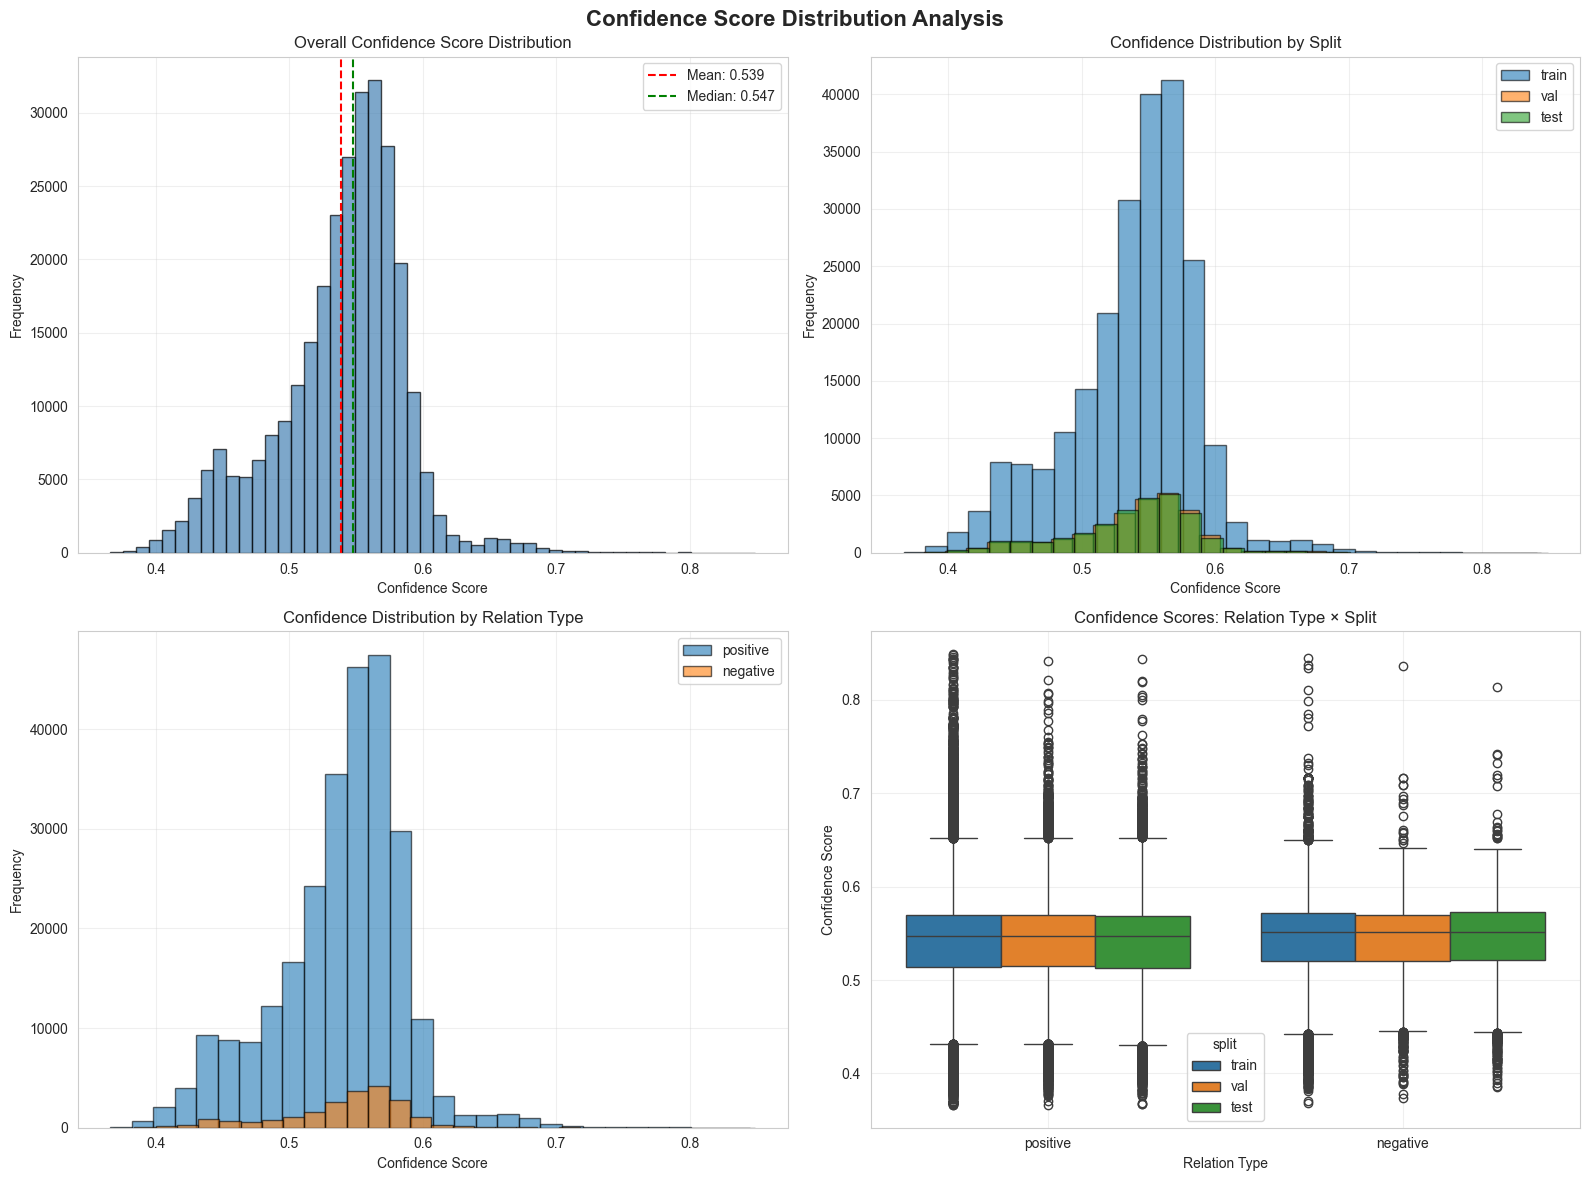

In [4]:
# Visualize confidence score distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Confidence Score Distribution Analysis', fontsize=16, fontweight='bold')

# Overall distribution
axes[0, 0].hist(df['confidence'], bins=50, alpha=0.7, edgecolor='black', color='steelblue')
axes[0, 0].axvline(df['confidence'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df["confidence"].mean():.3f}')
axes[0, 0].axvline(df['confidence'].median(), color='green', linestyle='--', 
                   label=f'Median: {df["confidence"].median():.3f}')
axes[0, 0].set_title('Overall Confidence Score Distribution')
axes[0, 0].set_xlabel('Confidence Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Distribution by split
for split in ['train', 'val', 'test']:
    split_data = df[df['split'] == split]['confidence']
    axes[0, 1].hist(split_data, bins=30, alpha=0.6, label=split, edgecolor='black')
axes[0, 1].set_title('Confidence Distribution by Split')
axes[0, 1].set_xlabel('Confidence Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Distribution by relation type
for rel_name in df['relation_name'].unique():
    rel_data = df[df['relation_name'] == rel_name]['confidence']
    axes[1, 0].hist(rel_data, bins=30, alpha=0.6, label=rel_name, edgecolor='black')
axes[1, 0].set_title('Confidence Distribution by Relation Type')
axes[1, 0].set_xlabel('Confidence Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Box plot by relation and split
df_melted = df.melt(id_vars=['relation_name', 'split'], value_vars=['confidence'], 
                    var_name='metric', value_name='value')
sns.boxplot(data=df, x='relation_name', y='confidence', hue='split', ax=axes[1, 1])
axes[1, 1].set_title('Confidence Scores: Relation Type × Split')
axes[1, 1].set_xlabel('Relation Type')
axes[1, 1].set_ylabel('Confidence Score')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Relation Type Analysis

STATISTICS BY RELATION TYPE
               confidence_mean  confidence_std  confidence_min  \
relation_name                                                    
negative                0.5415          0.0470          0.3683   
positive                0.5385          0.0485          0.3661   

               confidence_max  num_edges  unique_heads  unique_tails  
relation_name                                                         
negative               0.8447      21070          4154          3907  
positive               0.8490     265491         27279         20115  


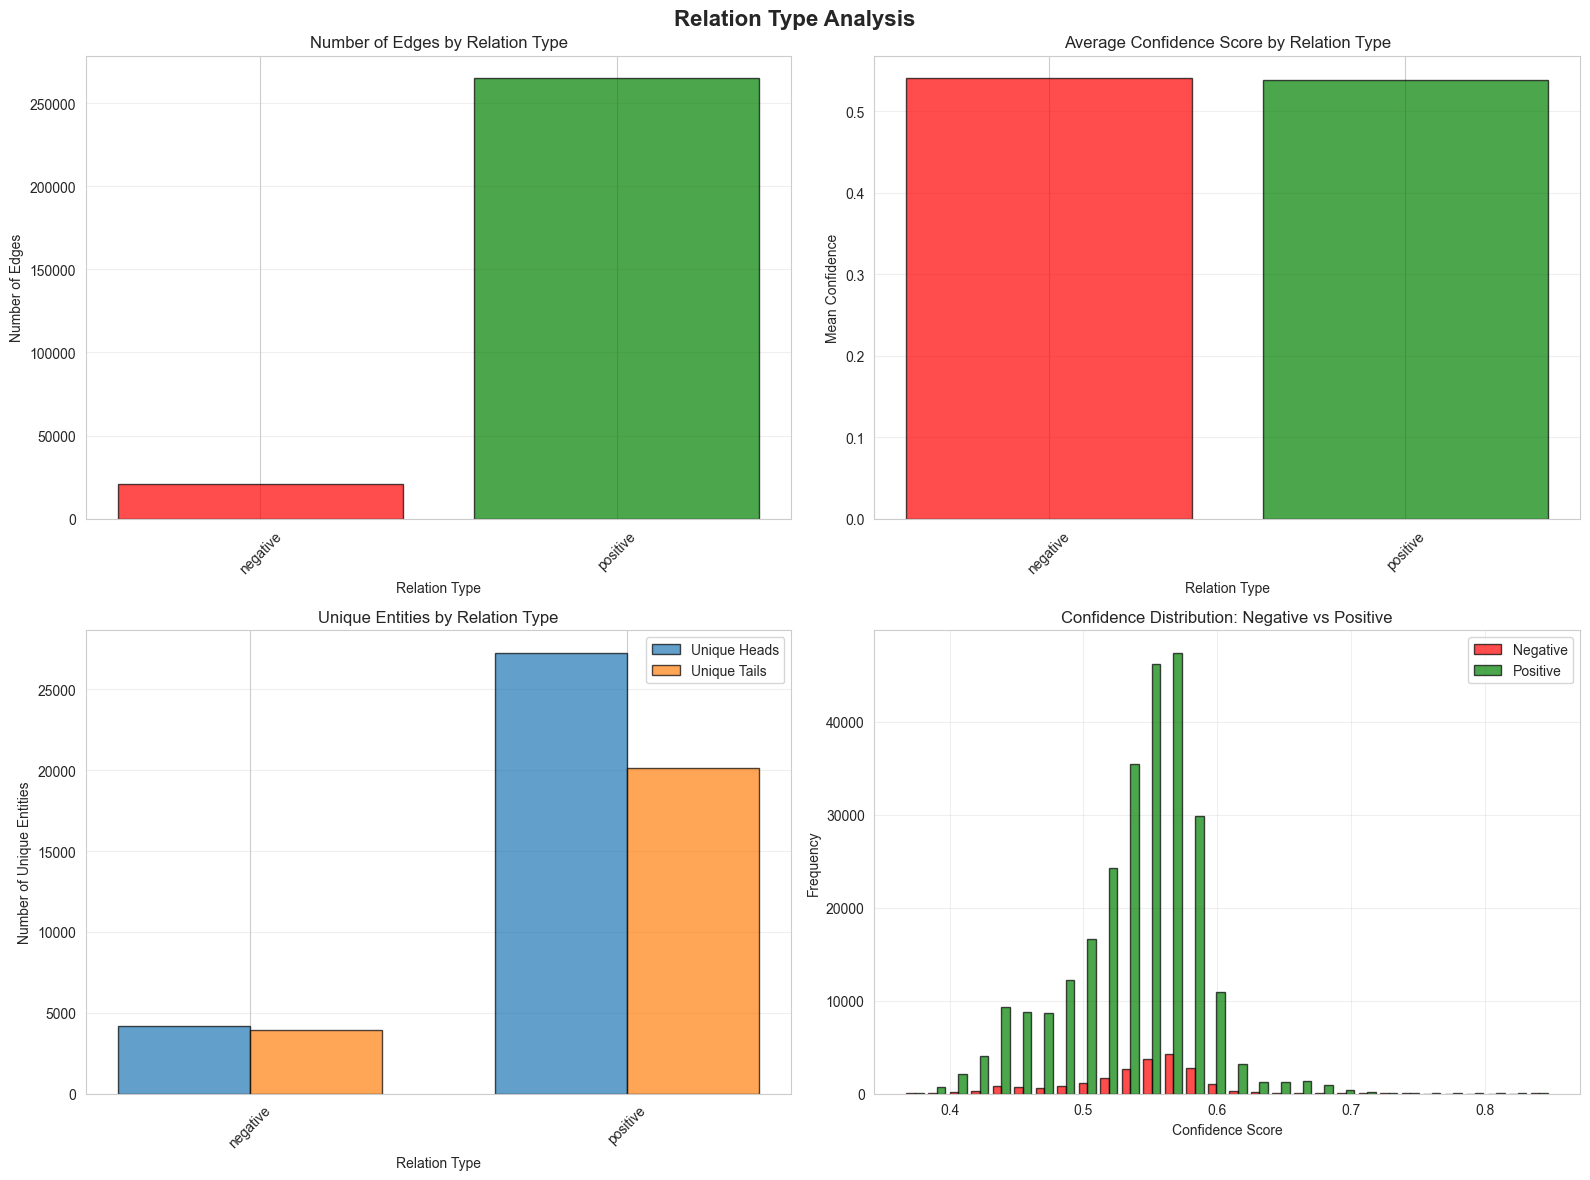

In [5]:
# Analyze by relation type
relation_stats = df.groupby('relation_name').agg({
    'confidence': ['mean', 'std', 'min', 'max', 'count'],
    'head': 'nunique',
    'tail': 'nunique'
}).round(4)

relation_stats.columns = ['_'.join(col).strip() for col in relation_stats.columns.values]
relation_stats = relation_stats.rename(columns={
    'confidence_count': 'num_edges',
    'head_nunique': 'unique_heads',
    'tail_nunique': 'unique_tails'
})

print("=" * 80)
print("STATISTICS BY RELATION TYPE")
print("=" * 80)
print(relation_stats)

# Visualize relation type analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Relation Type Analysis', fontsize=16, fontweight='bold')

relations = relation_stats.index.tolist()

# Number of edges by relation
axes[0, 0].bar(relations, relation_stats['num_edges'], alpha=0.7, edgecolor='black', 
               color=['red' if r == 'negative' else 'green' for r in relations])
axes[0, 0].set_title('Number of Edges by Relation Type')
axes[0, 0].set_xlabel('Relation Type')
axes[0, 0].set_ylabel('Number of Edges')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Mean confidence by relation
axes[0, 1].bar(relations, relation_stats['confidence_mean'], alpha=0.7, edgecolor='black',
               color=['red' if r == 'negative' else 'green' for r in relations])
axes[0, 1].set_title('Average Confidence Score by Relation Type')
axes[0, 1].set_xlabel('Relation Type')
axes[0, 1].set_ylabel('Mean Confidence')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Unique entities involved
unique_entities = relation_stats[['unique_heads', 'unique_tails']].values
x = np.arange(len(relations))
width = 0.35
axes[1, 0].bar(x - width/2, relation_stats['unique_heads'], width, label='Unique Heads', 
               alpha=0.7, edgecolor='black')
axes[1, 0].bar(x + width/2, relation_stats['unique_tails'], width, label='Unique Tails', 
               alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Unique Entities by Relation Type')
axes[1, 0].set_xlabel('Relation Type')
axes[1, 0].set_ylabel('Number of Unique Entities')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(relations, rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Confidence distribution comparison
negative_data = df[df['relation_name'] == 'negative']['confidence']
positive_data = df[df['relation_name'] == 'positive']['confidence']
axes[1, 1].hist([negative_data, positive_data], bins=30, alpha=0.7, 
                label=['Negative', 'Positive'], color=['red', 'green'], edgecolor='black')
axes[1, 1].set_title('Confidence Distribution: Negative vs Positive')
axes[1, 1].set_xlabel('Confidence Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Train/Val/Test Split Analysis

SPLIT STATISTICS

Edges per split:
split
test      28657
train    229248
val       28656
Name: count, dtype: int64

Confidence statistics by split:
          count      mean       std       min       25%       50%       75%  \
split                                                                         
test    28657.0  0.538284  0.048319  0.367308  0.513930  0.547047  0.569347   
train  229248.0  0.538744  0.048322  0.366712  0.514418  0.547486  0.569465   
val     28656.0  0.539131  0.048667  0.366068  0.514974  0.547827  0.569743   

            max  
split            
test   0.843802  
train  0.848985  
val    0.841204  

Relation distribution by split:
relation_name  negative  positive
split                            
test               2184     26473
train             16781    212467
val                2105     26551


TypeError: Axes.pie() got an unexpected keyword argument 'alpha'

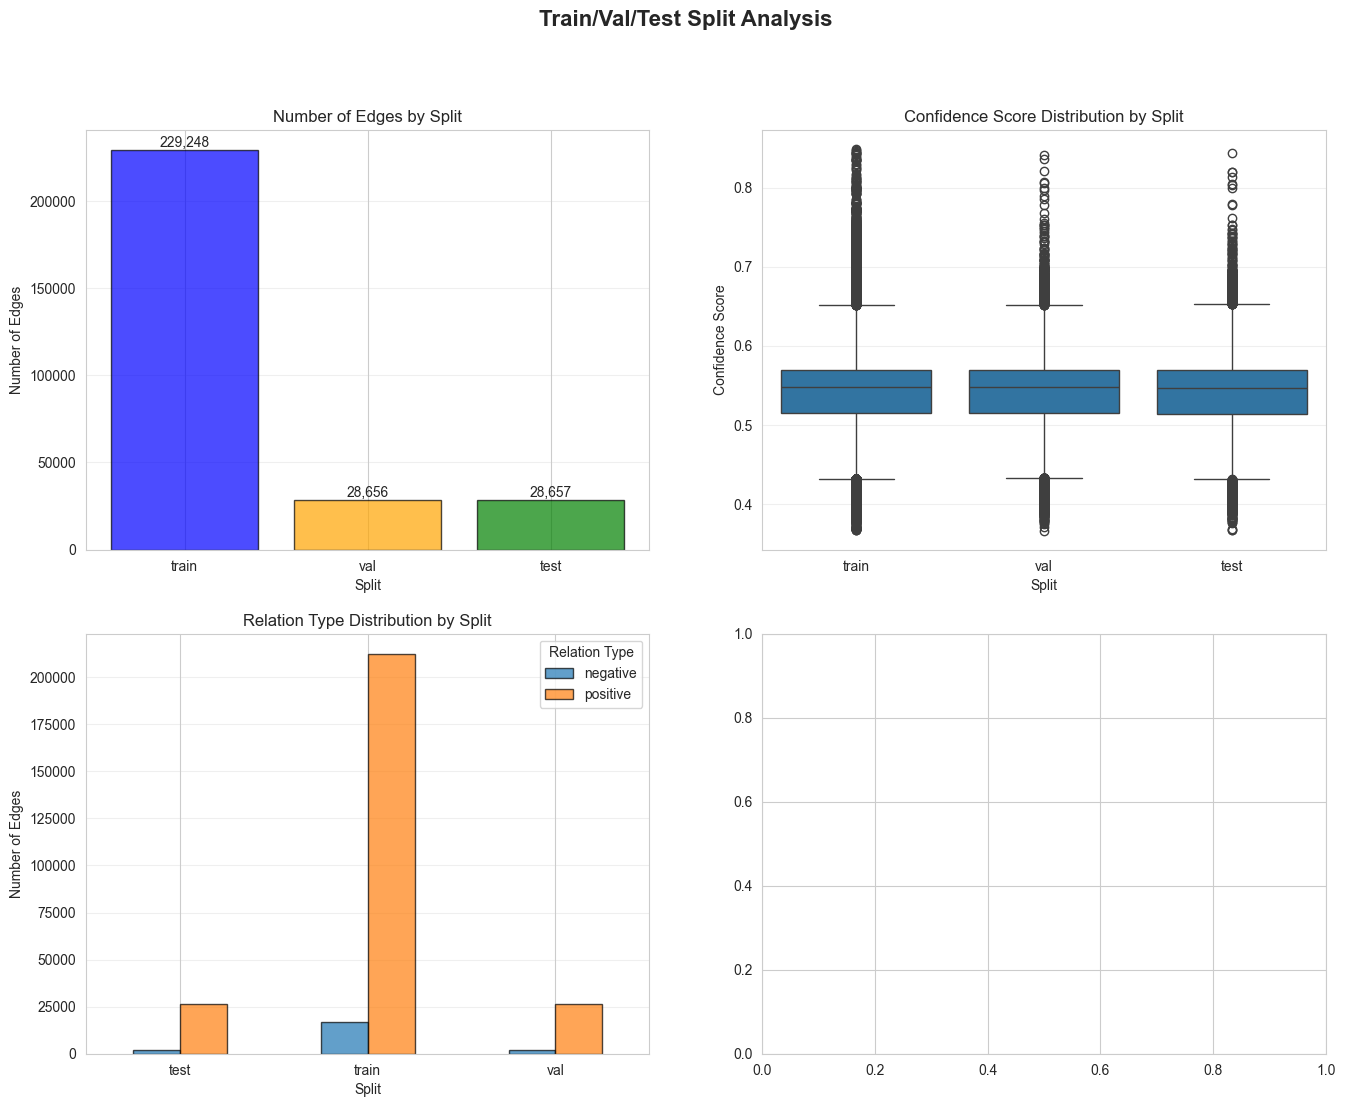

In [6]:
# Analyze data distribution across splits
split_stats = df.groupby('split').agg({
    'confidence': ['mean', 'std', 'min', 'max', 'count'],
    'head': 'nunique',
    'tail': 'nunique',
    'relation': lambda x: x.value_counts().to_dict()
}).round(4)

# Count relations per split
split_relation_counts = df.groupby(['split', 'relation_name']).size().unstack(fill_value=0)

print("=" * 80)
print("SPLIT STATISTICS")
print("=" * 80)
print(f"\nEdges per split:")
print(df['split'].value_counts().sort_index())
print(f"\nConfidence statistics by split:")
print(df.groupby('split')['confidence'].describe())
print(f"\nRelation distribution by split:")
print(split_relation_counts)

# Visualize split analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Train/Val/Test Split Analysis', fontsize=16, fontweight='bold')

# Edge counts by split
splits = ['train', 'val', 'test']
edge_counts = [len(df[df['split'] == s]) for s in splits]
axes[0, 0].bar(splits, edge_counts, alpha=0.7, edgecolor='black', color=['blue', 'orange', 'green'])
axes[0, 0].set_title('Number of Edges by Split')
axes[0, 0].set_xlabel('Split')
axes[0, 0].set_ylabel('Number of Edges')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, count in enumerate(edge_counts):
    axes[0, 0].text(i, count, f'{count:,}', ha='center', va='bottom')

# Confidence distribution by split (box plot)
sns.boxplot(data=df, x='split', y='confidence', ax=axes[0, 1], order=splits)
axes[0, 1].set_title('Confidence Score Distribution by Split')
axes[0, 1].set_xlabel('Split')
axes[0, 1].set_ylabel('Confidence Score')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Relation distribution by split
split_relation_counts.plot(kind='bar', ax=axes[1, 0], alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Relation Type Distribution by Split')
axes[1, 0].set_xlabel('Split')
axes[1, 0].set_ylabel('Number of Edges')
axes[1, 0].legend(title='Relation Type')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Split proportions
split_props = df['split'].value_counts(normalize=True) * 100
axes[1, 1].pie(split_props.values, labels=split_props.index, autopct='%1.1f%%', 
               startangle=90, colors=['blue', 'orange', 'green'], alpha=0.7)
axes[1, 1].set_title('Data Split Proportions')

plt.tight_layout()
plt.show()

## 4. Graph Structure Analysis

GRAPH STRUCTURE STATISTICS

Total entities: 35,776
Entities with edges: 35,776

Degree Statistics:
  In-degree  - Mean: 8.01, Median: 1.00, Max: 7,329
  Out-degree - Mean: 8.01, Median: 1.00, Max: 4,665
  Total degree - Mean: 16.02, Median: 2.00, Max: 8,667


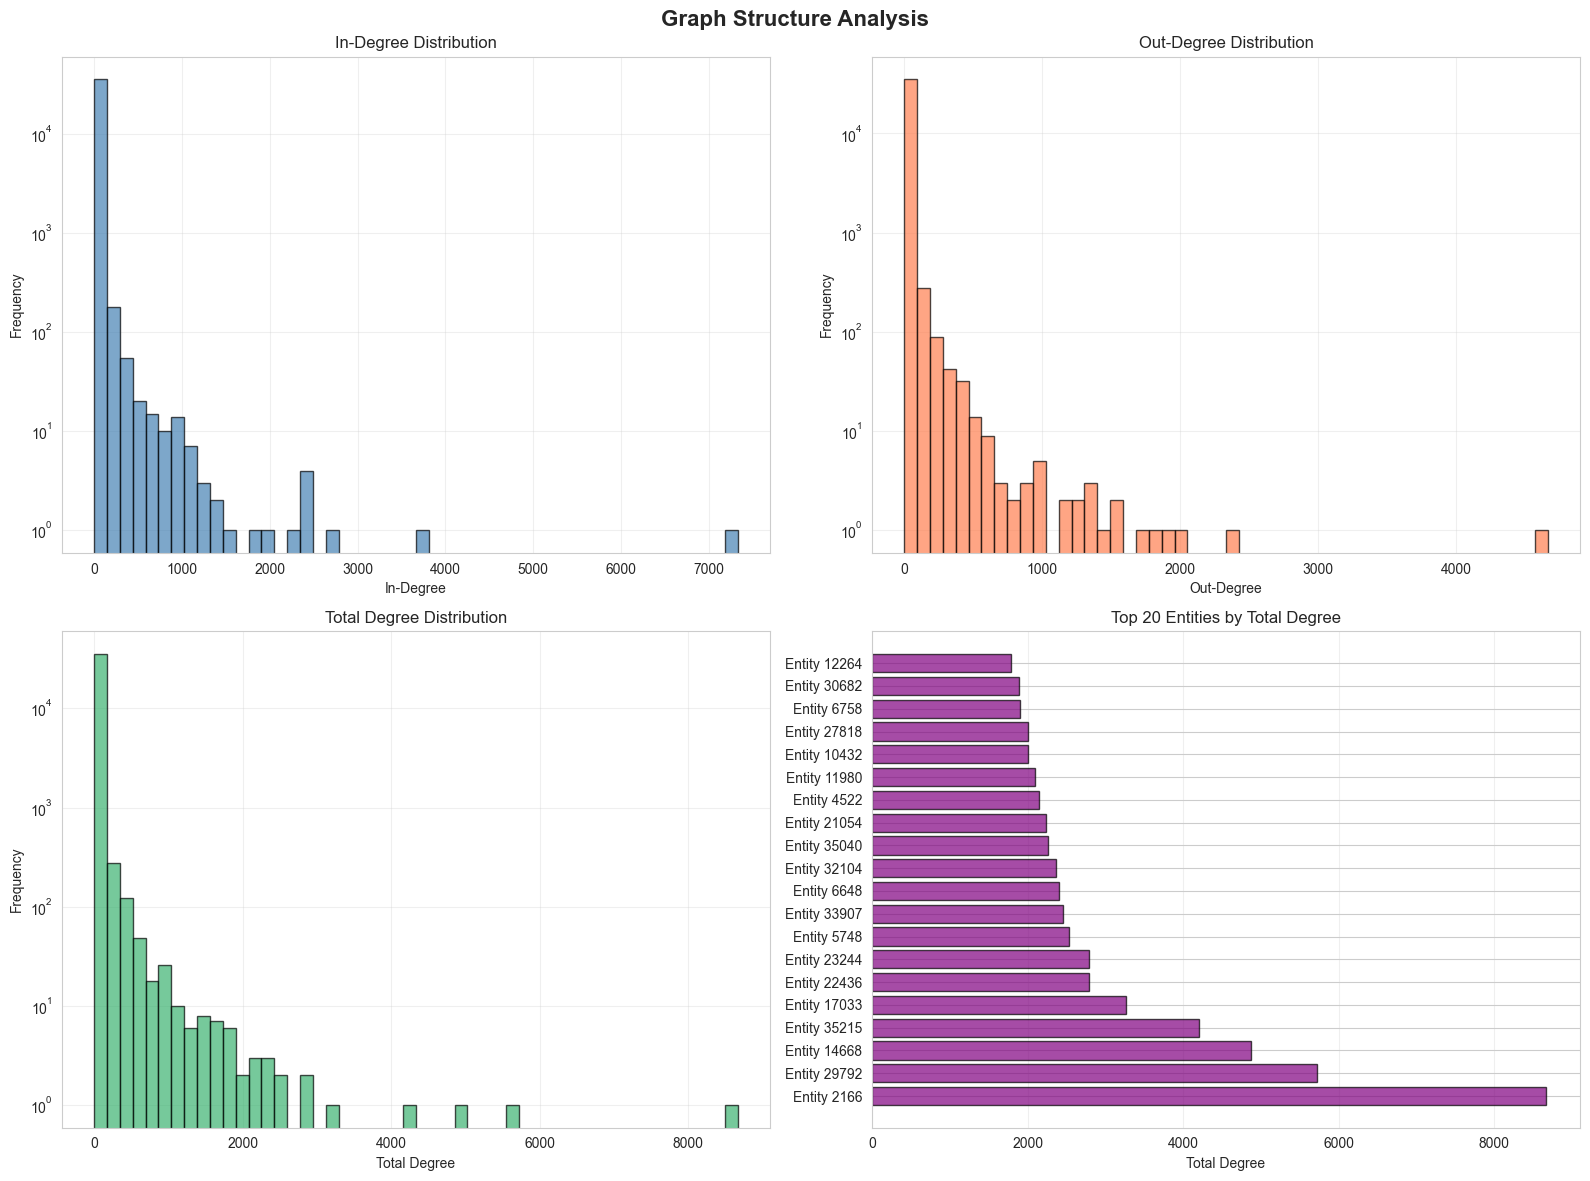

In [7]:
# Analyze graph structure: degree distributions
# Calculate in-degree and out-degree for each entity
head_counts = Counter(df['head'].values)
tail_counts = Counter(df['tail'].values)

# Get all unique entities
all_entities = set(df['head'].unique()) | set(df['tail'].unique())
in_degrees = [tail_counts.get(e, 0) for e in all_entities]
out_degrees = [head_counts.get(e, 0) for e in all_entities]
total_degrees = [in_degrees[i] + out_degrees[i] for i in range(len(all_entities))]

print("=" * 80)
print("GRAPH STRUCTURE STATISTICS")
print("=" * 80)
print(f"\nTotal entities: {len(all_entities):,}")
print(f"Entities with edges: {len(head_counts) + len(tail_counts) - len(set(head_counts.keys()) & set(tail_counts.keys())):,}")

print(f"\nDegree Statistics:")
print(f"  In-degree  - Mean: {np.mean(in_degrees):.2f}, Median: {np.median(in_degrees):.2f}, Max: {np.max(in_degrees):,}")
print(f"  Out-degree - Mean: {np.mean(out_degrees):.2f}, Median: {np.median(out_degrees):.2f}, Max: {np.max(out_degrees):,}")
print(f"  Total degree - Mean: {np.mean(total_degrees):.2f}, Median: {np.median(total_degrees):.2f}, Max: {np.max(total_degrees):,}")

# Visualize degree distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Graph Structure Analysis', fontsize=16, fontweight='bold')

# In-degree distribution (log scale)
axes[0, 0].hist(in_degrees, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
axes[0, 0].set_title('In-Degree Distribution')
axes[0, 0].set_xlabel('In-Degree')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# Out-degree distribution (log scale)
axes[0, 1].hist(out_degrees, bins=50, alpha=0.7, edgecolor='black', color='coral')
axes[0, 1].set_title('Out-Degree Distribution')
axes[0, 1].set_xlabel('Out-Degree')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# Total degree distribution (log scale)
axes[1, 0].hist(total_degrees, bins=50, alpha=0.7, edgecolor='black', color='mediumseagreen')
axes[1, 0].set_title('Total Degree Distribution')
axes[1, 0].set_xlabel('Total Degree')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Top entities by degree
top_n = 20
top_entities = sorted(zip(all_entities, total_degrees), key=lambda x: x[1], reverse=True)[:top_n]
top_entity_ids, top_degs = zip(*top_entities)

axes[1, 1].barh(range(len(top_entity_ids)), top_degs, alpha=0.7, edgecolor='black', color='purple')
axes[1, 1].set_yticks(range(len(top_entity_ids)))
axes[1, 1].set_yticklabels([f'Entity {eid}' for eid in top_entity_ids])
axes[1, 1].set_title(f'Top {top_n} Entities by Total Degree')
axes[1, 1].set_xlabel('Total Degree')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 5. Confidence Score Analysis by Relation Type

CONFIDENCE SCORE ANALYSIS BY RELATION TYPE

Negative Sentiment Links:
  Count: 21,070 (7.4%)
  Confidence - Mean: 0.5415, Std: 0.0470
  Confidence - Min: 0.3683, Max: 0.8447

Positive Sentiment Links:
  Count: 265,491 (92.6%)
  Confidence - Mean: 0.5385, Std: 0.0485
  Confidence - Min: 0.3661, Max: 0.8490


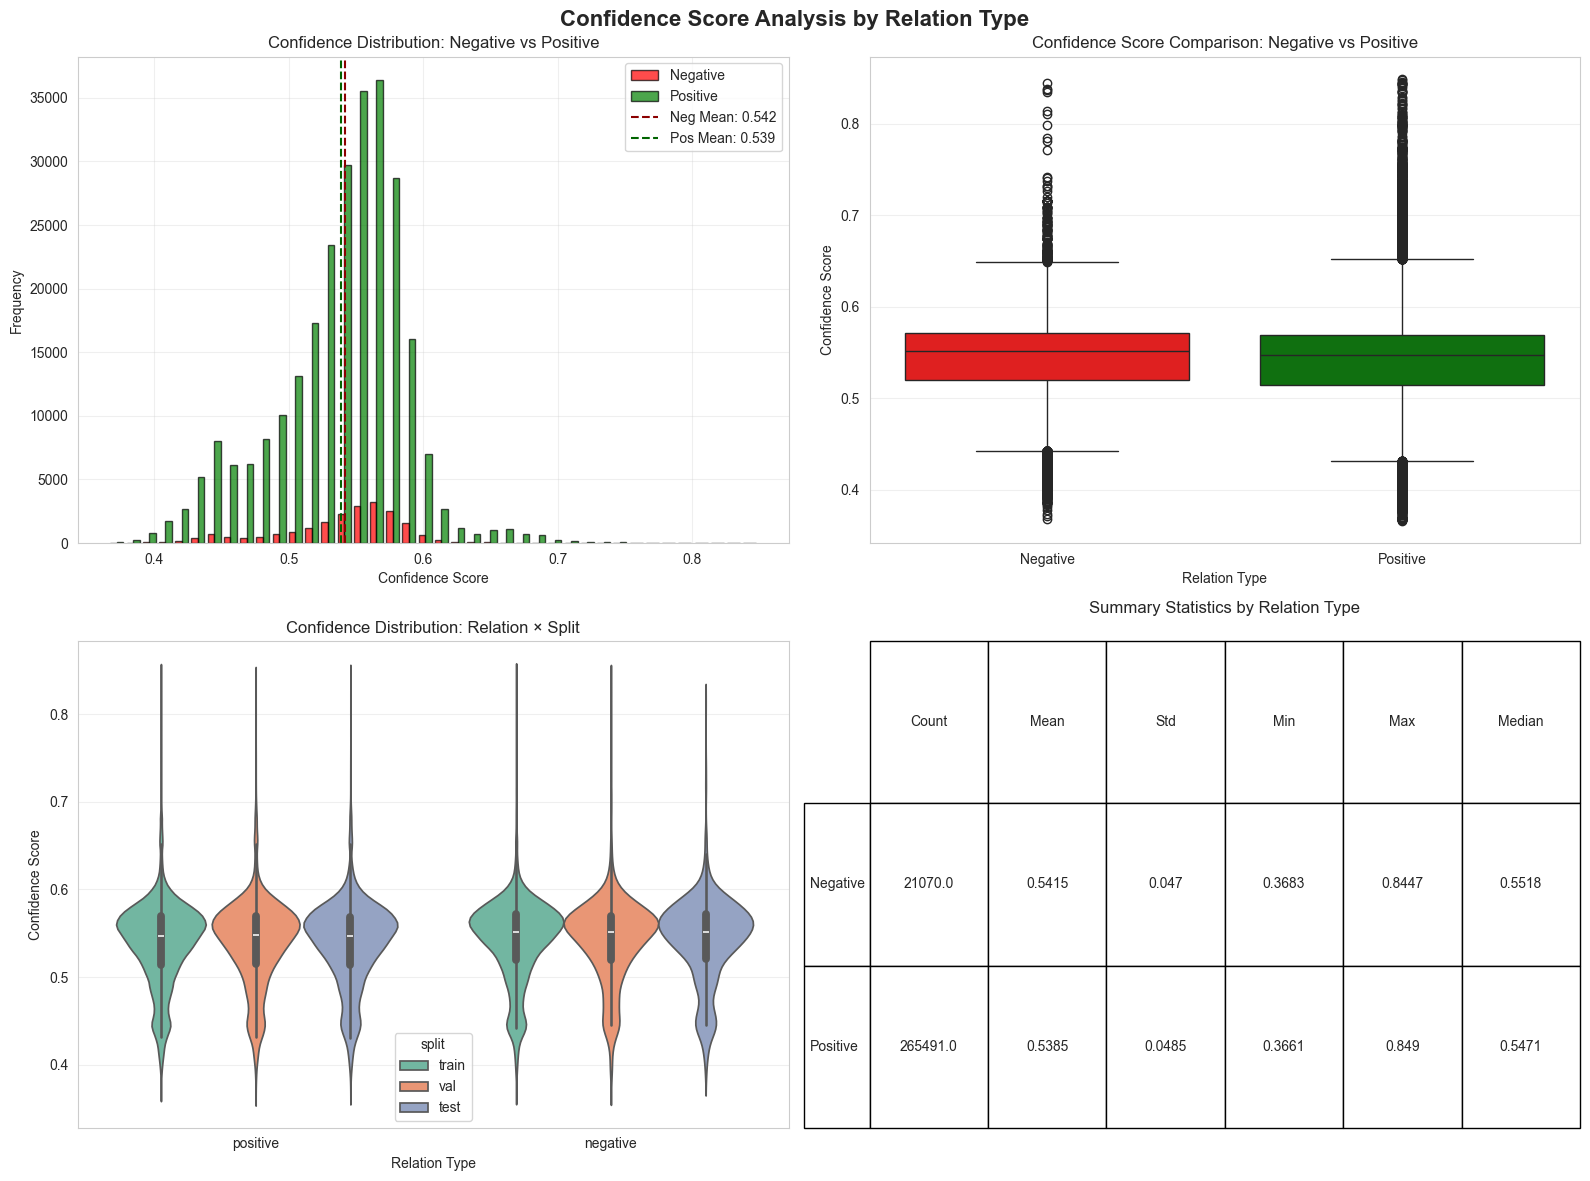

In [8]:
# Detailed analysis of confidence scores by relation type
negative_df = df[df['relation_name'] == 'negative']
positive_df = df[df['relation_name'] == 'positive']

print("=" * 80)
print("CONFIDENCE SCORE ANALYSIS BY RELATION TYPE")
print("=" * 80)
print(f"\nNegative Sentiment Links:")
print(f"  Count: {len(negative_df):,} ({len(negative_df)/len(df)*100:.1f}%)")
print(f"  Confidence - Mean: {negative_df['confidence'].mean():.4f}, Std: {negative_df['confidence'].std():.4f}")
print(f"  Confidence - Min: {negative_df['confidence'].min():.4f}, Max: {negative_df['confidence'].max():.4f}")

print(f"\nPositive Sentiment Links:")
print(f"  Count: {len(positive_df):,} ({len(positive_df)/len(df)*100:.1f}%)")
print(f"  Confidence - Mean: {positive_df['confidence'].mean():.4f}, Std: {positive_df['confidence'].std():.4f}")
print(f"  Confidence - Min: {positive_df['confidence'].min():.4f}, Max: {positive_df['confidence'].max():.4f}")

# Visualize confidence analysis by relation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Confidence Score Analysis by Relation Type', fontsize=16, fontweight='bold')

# Comparison histogram
axes[0, 0].hist([negative_df['confidence'], positive_df['confidence']], 
                bins=40, alpha=0.7, label=['Negative', 'Positive'], 
                color=['red', 'green'], edgecolor='black')
axes[0, 0].axvline(negative_df['confidence'].mean(), color='darkred', linestyle='--', 
                   label=f'Neg Mean: {negative_df["confidence"].mean():.3f}')
axes[0, 0].axvline(positive_df['confidence'].mean(), color='darkgreen', linestyle='--', 
                   label=f'Pos Mean: {positive_df["confidence"].mean():.3f}')
axes[0, 0].set_title('Confidence Distribution: Negative vs Positive')
axes[0, 0].set_xlabel('Confidence Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Box plot comparison
comparison_df = pd.concat([
    pd.DataFrame({'confidence': negative_df['confidence'], 'relation': 'Negative'}),
    pd.DataFrame({'confidence': positive_df['confidence'], 'relation': 'Positive'})
])
sns.boxplot(data=comparison_df, x='relation', y='confidence', ax=axes[0, 1], 
            palette=['red', 'green'])
axes[0, 1].set_title('Confidence Score Comparison: Negative vs Positive')
axes[0, 1].set_xlabel('Relation Type')
axes[0, 1].set_ylabel('Confidence Score')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Confidence by relation and split
sns.violinplot(data=df, x='relation_name', y='confidence', hue='split', 
               ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Confidence Distribution: Relation × Split')
axes[1, 0].set_xlabel('Relation Type')
axes[1, 0].set_ylabel('Confidence Score')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Summary statistics table
summary_data = {
    'Negative': {
        'Count': len(negative_df),
        'Mean': negative_df['confidence'].mean(),
        'Std': negative_df['confidence'].std(),
        'Min': negative_df['confidence'].min(),
        'Max': negative_df['confidence'].max(),
        'Median': negative_df['confidence'].median()
    },
    'Positive': {
        'Count': len(positive_df),
        'Mean': positive_df['confidence'].mean(),
        'Std': positive_df['confidence'].std(),
        'Min': positive_df['confidence'].min(),
        'Max': positive_df['confidence'].max(),
        'Median': positive_df['confidence'].median()
    }
}
summary_df = pd.DataFrame(summary_data).T
axes[1, 1].axis('off')
table = axes[1, 1].table(cellText=summary_df.round(4).values,
                         rowLabels=summary_df.index,
                         colLabels=summary_df.columns,
                         cellLoc='center',
                         loc='center',
                         bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
axes[1, 1].set_title('Summary Statistics by Relation Type', pad=20)

plt.tight_layout()
plt.show()

## 6. Dataset Summary

In [9]:
# Final summary of the dataset
print("=" * 80)
print("DATASET SUMMARY")
print("=" * 80)

print(f"\nDataset Path: {dataset_path}")
print(f"\nBasic Statistics:")
print(f"  Total entities (subreddits): {len(entity2id):,}")
print(f"  Total relations: {len(relation2id)}")
print(f"  Total edges: {len(df):,}")

print(f"\nEdge Distribution:")
print(f"  Train: {len(df[df['split'] == 'train']):,} ({len(df[df['split'] == 'train'])/len(df)*100:.1f}%)")
print(f"  Validation: {len(df[df['split'] == 'val']):,} ({len(df[df['split'] == 'val'])/len(df)*100:.1f}%)")
print(f"  Test: {len(df[df['split'] == 'test']):,} ({len(df[df['split'] == 'test'])/len(df)*100:.1f}%)")

print(f"\nRelation Distribution:")
for rel_name in df['relation_name'].unique():
    rel_count = len(df[df['relation_name'] == rel_name])
    print(f"  {rel_name}: {rel_count:,} ({rel_count/len(df)*100:.1f}%)")

print(f"\nConfidence Score Statistics:")
print(f"  Mean: {df['confidence'].mean():.4f}")
print(f"  Std: {df['confidence'].std():.4f}")
print(f"  Min: {df['confidence'].min():.4f}")
print(f"  Max: {df['confidence'].max():.4f}")
print(f"  Median: {df['confidence'].median():.4f}")

print(f"\nGraph Structure:")
print(f"  Entities with edges: {len(set(df['head'].unique()) | set(df['tail'].unique())):,}")
print(f"  Average in-degree: {np.mean(in_degrees):.2f}")
print(f"  Average out-degree: {np.mean(out_degrees):.2f}")
print(f"  Average total degree: {np.mean(total_degrees):.2f}")

print(f"\nConfidence by Relation Type:")
for rel_name in df['relation_name'].unique():
    rel_data = df[df['relation_name'] == rel_name]['confidence']
    print(f"  {rel_name}: Mean={rel_data.mean():.4f}, Std={rel_data.std():.4f}")

print("\n" + "=" * 80)

DATASET SUMMARY

Dataset Path: /Users/sarasaad/Documents/BDMA /CentraleSupelec/newbdrp/bdrp/new datasets/reddit/reddit_converted

Basic Statistics:
  Total entities (subreddits): 35,776
  Total relations: 2
  Total edges: 286,561

Edge Distribution:
  Train: 229,248 (80.0%)
  Validation: 28,656 (10.0%)
  Test: 28,657 (10.0%)

Relation Distribution:
  positive: 265,491 (92.6%)
  negative: 21,070 (7.4%)

Confidence Score Statistics:
  Mean: 0.5387
  Std: 0.0484
  Min: 0.3661
  Max: 0.8490
  Median: 0.5475

Graph Structure:
  Entities with edges: 35,776
  Average in-degree: 8.01
  Average out-degree: 8.01
  Average total degree: 16.02

Confidence by Relation Type:
  positive: Mean=0.5385, Std=0.0485
  negative: Mean=0.5415, Std=0.0470

